In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd

CLEAN_DATA_PATH = '../data/processed/train_clean.parquet'
EMBEDDINGS_PATH = '../data/raw/item_embeddings.npz'

df = pd.read_parquet(CLEAN_DATA_PATH)
print(f"Загружено строк датасета: {len(df):,}")

# Загружаем .npz файл
item_embeddings_raw = np.load(EMBEDDINGS_PATH, allow_pickle=True)

# Вытаскиваем два быстрых массива напрямую
emb_item_ids = item_embeddings_raw['item_id']
emb_vectors = item_embeddings_raw['embedding'].astype(np.float32)

print(f"Успешно загружена матрица эмбеддингов для {emb_item_ids.shape[0]:,} видео")

Загружено строк датасета: 40,618,962
Успешно загружена матрица эмбеддингов для 19,627,601 видео


Генерация "счетчиков"
популярность автора
активность пользователя

In [3]:
def create_agg_features(df):

    #Популярность автора - средний Watch Ratio
    author_stats = df.groupby('author_id')['target'].agg(['mean', 'count']).reset_index()
    author_stats.columns = ['author_id', 'author_mean_target', 'author_video_count']

    #Активность пользователя - сколько видео он посмотрел и его средний досмотр
    user_stats = df.groupby('user_id')['target'].agg(['mean', 'count']).reset_index()
    user_stats.columns = ['user_id', 'user_mean_target', 'user_watch_count']

    df = df.merge(author_stats, on='author_id', how='left')
    df = df.merge(user_stats, on='user_id', how='left')

    return df

df = create_agg_features(df)
print("Готово. Новые столбцы:", ['author_mean_target', 'user_mean_target'])

Готово. Новые столбцы: ['author_mean_target', 'user_mean_target']


Заменим Bool значения на 1,0 и создадим новую фичу как engagement_score:
$$EngagementScore = (Like + Share + Bookmark + ClickAuthor + OpenComments) - Dislike$$

In [4]:
def transform_binary_and_categories(df):

    #Список булевых столбцов
    bool_cols = ['like', 'dislike', 'share', 'bookmark', 'click_on_author', 'open_comments']
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    #Создаем комплексную фичу Engagement Score
    df['engagement_score'] = df[['like', 'share', 'bookmark', 'click_on_author', 'open_comments']].sum(axis=1)
    if 'dislike' in df.columns:
        df['engagement_score'] = df['engagement_score'] - df['dislike']

    print("Категориальные и бинарные признаки обработаны.")
    return df

df = transform_binary_and_categories(df)
display(df[['user_id', 'item_id', 'engagement_score', 'target']].head())

Категориальные и бинарные признаки обработаны.


,user_id,item_id,engagement_score,target
0,4498832,289321432,0,1.000000
1,3935673,524285128,0,0.136986
2,3591171,600360983,0,0.368421
3,1291951,134985354,0,1.000000
4,1069595,370435754,0,0.071429


Теперь у модели есть не только target, но и Engagement Score.

Если юзер посмотрел видео на 20% (target=0.2), но при этом поставил лайк и сделал репост (engagement_score=2), модель поймет, что это видео было ОЧЕНЬ интересным, просто коротким или прерванным звонком.

Займемся агрегированными признаками и посчитаем средние показатели для каждого author_id и user_id.

In [5]:
def create_stats_features(df):

    author_stats = df.groupby('author_id').agg({
        'target': 'mean',
        'engagement_score': 'mean',
        'item_id': 'count'
    }).reset_index()

    author_stats.columns = ['author_id', 'author_avg_target', 'author_avg_engagement', 'author_popularity']

    user_stats = df.groupby('user_id').agg({
        'target': 'mean',
        'engagement_score': 'mean',
        'item_id': 'count'
    }).reset_index()

    user_stats.columns = ['user_id', 'user_avg_target', 'user_avg_engagement', 'user_activity']

    df = df.merge(author_stats, on='author_id', how='left')
    df = df.merge(user_stats, on='user_id', how='left')

    print("Статистики успешно добавлены.")
    return df

df = create_stats_features(df)
display(df[['author_id', 'author_avg_target', 'user_id', 'user_avg_target']].head())

Статистики успешно добавлены.


,author_id,author_avg_target,user_id,user_avg_target
0,285593,0.648670,4498832,0.680623
1,239962,0.527395,3935673,0.482548
2,586575,0.572725,3591171,0.651666
3,1051229,0.548375,1291951,0.590401
4,702084,0.481873,1069595,0.556976


author_avg_engagement: Если у автора этот показатель высокий, значит, его контент провоцирует людей на действия. Модель быстро поймет, что его видео хайповые.

user_avg_target: Есть пользователи, которые смотрят всё до конца, а есть листатели, которые закрывают всё через секунду. Без этой фичи модель будет штрафовать видео за то, что листатель его закрыл, а теперь она поймет: «А, ну этот юзер всегда так делает, видео тут ни при чем».

Также я создал категорию «Длительность видео», так как люди по-разному смотрят короткие (5 сек) и длинные (60 сек) ролики.

In [6]:
def create_video_type_features(df):
    # 0-15 сек: Shorts, 15-30: Medium, 30+: Long
    df['video_duration_type'] = pd.cut(df['duration'],
                                       bins=[0, 15, 30, 300],
                                       labels=[1, 2, 3]).astype(int)

    print("Признак типа длительности видео создан.")
    return df

df = create_video_type_features(df)

Признак типа длительности видео создан.


ALS-разложения в СР2

In [7]:
!pip install implicit scipy numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import implicit
from scipy.sparse import csr_matrix
import pickle
import os
import numpy as np

def apply_als_decomposition(df):
    print("Запуск ALS разложения...")

    # 1. Кодируем в плотные индексы
    df['user_id_idx'] = df['user_id'].astype('category').cat.codes
    df['item_id_idx'] = df['item_id'].astype('category').cat.codes

    # 2. Строим разреженную матрицу
    print("Сборка разреженной матрицы взаимодействий...")
    sparse_user_item = csr_matrix((df['target'], (df['user_id_idx'], df['item_id_idx'])))

    # 3. Инициализация и обучение
    print("Обучение модели ALS (Latent Factors = 32)...")
    model_als = implicit.als.AlternatingLeastSquares(
        factors=32,
        iterations=15,
        regularization=0.1,
        random_state=42
    )
    model_als.fit(sparse_user_item)

    # 4. Сохраняем модель
    MODELS_DIR = '../models/'
    os.makedirs(MODELS_DIR, exist_ok=True)
    with open(os.path.join(MODELS_DIR, 'als_model.pkl'), 'wb') as f:
        pickle.dump(model_als, f)
    print("Модель ALS успешно сохранена.")

    # 5. Извлекаем скрытые факторы
    user_factors = model_als.user_factors
    item_factors = model_als.item_factors

    # 6. ОПТИМИЗИРОВАННЫЙ РАСЧЕТ БАТЧАМИ (Память больше не упадет)
    print("Расчет финального признака als_score (батч-режим)...")

    # Создаем пустой массив нужного размера под результаты
    als_scores = np.zeros(len(df), dtype=np.float32)

    # Размер кусочка, который обрабатываем за раз
    batch_size = 500000

    # Переводим индексы в numpy-массивы для максимального ускорения
    u_idx = df['user_id_idx'].values
    i_idx = df['item_id_idx'].values

    for start_idx in range(0, len(df), batch_size):
        end_idx = start_idx + batch_size

        # Вырезаем кусочек индексов для текущего батча
        batch_u = u_idx[start_idx:end_idx]
        batch_i = i_idx[start_idx:end_idx]

        # Считаем скалярное произведение только для этого кусочка
        batch_score = (user_factors[batch_u] * item_factors[batch_i]).sum(axis=1)

        # Записываем результат на свое место
        als_scores[start_idx:end_idx] = batch_score

    # Записываем готовый массив обратно в DataFrame
    df['als_score'] = als_scores

    # 7. Удаляем временные индексные столбцы
    df = df.drop(columns=['user_id_idx', 'item_id_idx'])

    print("ALS фича успешно создана и добавлена в датасет.")
    return df

# Запускаем функцию
df = apply_als_decomposition(df)
display(df[['user_id', 'item_id', 'als_score', 'target']].head())

C:\Users\kioto\hseml-group-project-satarovvladimir-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Запуск ALS разложения...
Сборка разреженной матрицы взаимодействий...
Обучение модели ALS (Latent Factors = 32)...


C:\Users\kioto\hseml-group-project-satarovvladimir-2\.venv\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 24 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 15/15 [00:11<00:00,  1.26it/s]


Модель ALS успешно сохранена.
Расчет финального признака als_score (батч-режим)...
ALS фича успешно создана и добавлена в датасет.


,user_id,item_id,als_score,target
0,4498832,289321432,0.018440,1.000000
1,3935673,524285128,0.036344,0.136986
2,3591171,600360983,0.154857,0.368421
3,1291951,134985354,0.051460,1.000000
4,1069595,370435754,0.010294,0.071429


In [9]:
def apply_embedding_similarity(df, emb_item_ids, emb_vectors):
    print("Расчет контентного сходства по эмбеддингам...")

    # Нормализуем исходную матрицу векторов видео для косинусного сходства (длина каждого вектора = 1)
    print("Нормализация глобальной матрицы эмбеддингов видео...")
    norms = np.linalg.norm(emb_vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    emb_vectors_norm = emb_vectors / norms

    # Создаем быстрый маппинг: item_id -> его индекс в матрице эмбеддингов
    print("Создание индекса поиска...")
    id_to_idx = pd.Series(np.arange(len(emb_item_ids)), index=emb_item_ids)

    # Находим индексы в матрице эмбеддингов только для тех видео, которые есть в нашем df
    print("Сопоставление видео из датасета с матрицей эмбеддингов...")
    df_item_idxs = id_to_idx.reindex(df['item_id']).values
    # Если какого-то видео нет в эмбеддингах, присваиваем временный индекс -1
    df_item_idxs = np.nan_to_num(df_item_idxs, nan=-1).astype(np.int32)

    # 2. Строим профиль интересов пользователя (User Profile)
    print("Построение векторов интересов пользователей...")
    df['item_emb_idx'] = df_item_idxs

    # Отбираем только качественные взаимодействия для профиля вкусов (target > 0.5)
    # И исключаем видео, для которых не нашлось эмбеддингов (индекс == -1)
    good_interactions = df[(df['target'] > 0.5) & (df['item_emb_idx'] != -1)][['user_id', 'item_emb_idx']]

    # Собираем средний вектор для каждого юзера
    user_profiles = {}
    emb_dim = 64
    global_mean_vector = np.zeros(emb_dim, dtype=np.float32)

    for u_id, group in good_interactions.groupby('user_id'):
        vector_indices = group['item_emb_idx'].values
        user_profiles[u_id] = emb_vectors_norm[vector_indices].mean(axis=0)

    # 3. Расчет косинусного сходства БАТЧАМИ (защита памяти)
    print("Вычисление финального признака embedding_similarity_score...")
    similarity_scores = np.zeros(len(df), dtype=np.float32)
    batch_size = 500000
    user_ids = df['user_id'].values

    for start_idx in range(0, len(df), batch_size):
        end_idx = start_idx + batch_size

        batch_users = user_ids[start_idx:end_idx]
        batch_item_indices = df_item_idxs[start_idx:end_idx]

        # Получаем нормализованные векторы видео для текущего батча
        # Если индекс -1 (нет эмбеддинга), берем нулевой вектор
        batch_item_vectors = np.where(
            (batch_item_indices == -1)[:, None],
            global_mean_vector,
            emb_vectors_norm[batch_item_indices]
        )

        # Получаем профили пользователей для текущего батча
        batch_user_vectors = np.array([user_profiles.get(u, global_mean_vector) for u in batch_users], dtype=np.float32)

        # Нормализуем профили пользователей
        u_norms = np.linalg.norm(batch_user_vectors, axis=1, keepdims=True)
        u_norms[u_norms == 0] = 1.0
        batch_user_vectors_norm = batch_user_vectors / u_norms

        # Скалярное произведение — получаем Косинусное сходство
        batch_sim = (batch_user_vectors_norm * batch_item_vectors).sum(axis=1)
        similarity_scores[start_idx:end_idx] = batch_sim

    # Записываем готовую фичу в таблицу
    df['embedding_similarity_score'] = similarity_scores

    # Удаляем временную техническую колонку
    df = df.drop(columns=['item_emb_idx'])

    print("Признак контентного сходства успешно создан и внедрен!")
    return df

# Запускаем расчет фичи
df = apply_embedding_similarity(df, emb_item_ids, emb_vectors)
display(df[['user_id', 'item_id', 'embedding_similarity_score', 'target']].head())

Расчет контентного сходства по эмбеддингам...
Нормализация глобальной матрицы эмбеддингов видео...
Создание индекса поиска...
Сопоставление видео из датасета с матрицей эмбеддингов...
Построение векторов интересов пользователей...
Вычисление финального признака embedding_similarity_score...
Признак контентного сходства успешно создан и внедрен!


,user_id,item_id,embedding_similarity_score,target
0,4498832,289321432,0.478669,1.000000
1,3935673,524285128,0.734857,0.136986
2,3591171,600360983,0.424189,0.368421
3,1291951,134985354,0.449585,1.000000
4,1069595,370435754,0.665904,0.071429


Проверяем данные еще раз отдельно на Nun и сохраняем в новую БД

In [10]:
from src.data_loader import save_processed_data

if df.isnull().values.any():
    print("Заполнение пропусков в новых признаках...")
    df = df.fillna(0)

OUTPUT_DIR = '../data/processed/'
FILE_NAME = 'train_features.parquet'

save_processed_data(df, OUTPUT_DIR, FILE_NAME)
print(f"Итоговая таблица: {df.shape[0]:,} строк на {df.shape[1]} колонок")
display(df.head())
df.info()

Файл сохранен: ../data/processed/train_features.parquet
Итоговая таблица: 40,618,962 строк на 34 колонок


,user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,...,engagement_score,author_avg_target,author_avg_engagement,author_popularity,user_avg_target,user_avg_engagement,user_activity,video_duration_type,als_score,embedding_similarity_score
0,4498832,289321432,0,0,0,52,0,0,0,0,...,0,0.648670,0.018708,3421,0.680623,0.003468,865,3,0.018440,0.478669
1,3935673,524285128,0,1,1,10,0,0,0,0,...,0,0.527395,0.081636,29607,0.482548,0.042616,1009,3,0.036344,0.734857
2,3591171,600360983,0,0,0,7,0,0,0,0,...,0,0.572725,0.145379,41691,0.651666,0.104825,601,2,0.154857,0.424189
3,1291951,134985354,0,0,0,15,0,0,0,0,...,0,0.548375,0.016359,41384,0.590401,0.020073,548,1,0.051460,0.449585
4,1069595,370435754,0,1,1,1,0,0,0,0,...,0,0.481873,0.014578,5625,0.556976,0.065764,1551,1,0.010294,0.665904


<class 'pandas.DataFrame'>
RangeIndex: 40618962 entries, 0 to 40618961
Data columns (total 34 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   user_id                     uint32 
 1   item_id                     uint32 
 2   place                       uint8  
 3   platform                    uint8  
 4   agent                       uint8  
 5   timespent                   uint8  
 6   like                        int64  
 7   dislike                     int64  
 8   share                       int64  
 9   bookmark                    int64  
 10  click_on_author             int64  
 11  open_comments               int64  
 12  author_id                   uint32 
 13  duration                    uint8  
 14  train_interactions_rank_x   uint32 
 15  age                         uint8  
 16  gender                      uint8  
 17  geo                         uint8  
 18  train_interactions_rank_y   uint32 
 19  target                      fl

Соотношение Таргетов к фичам

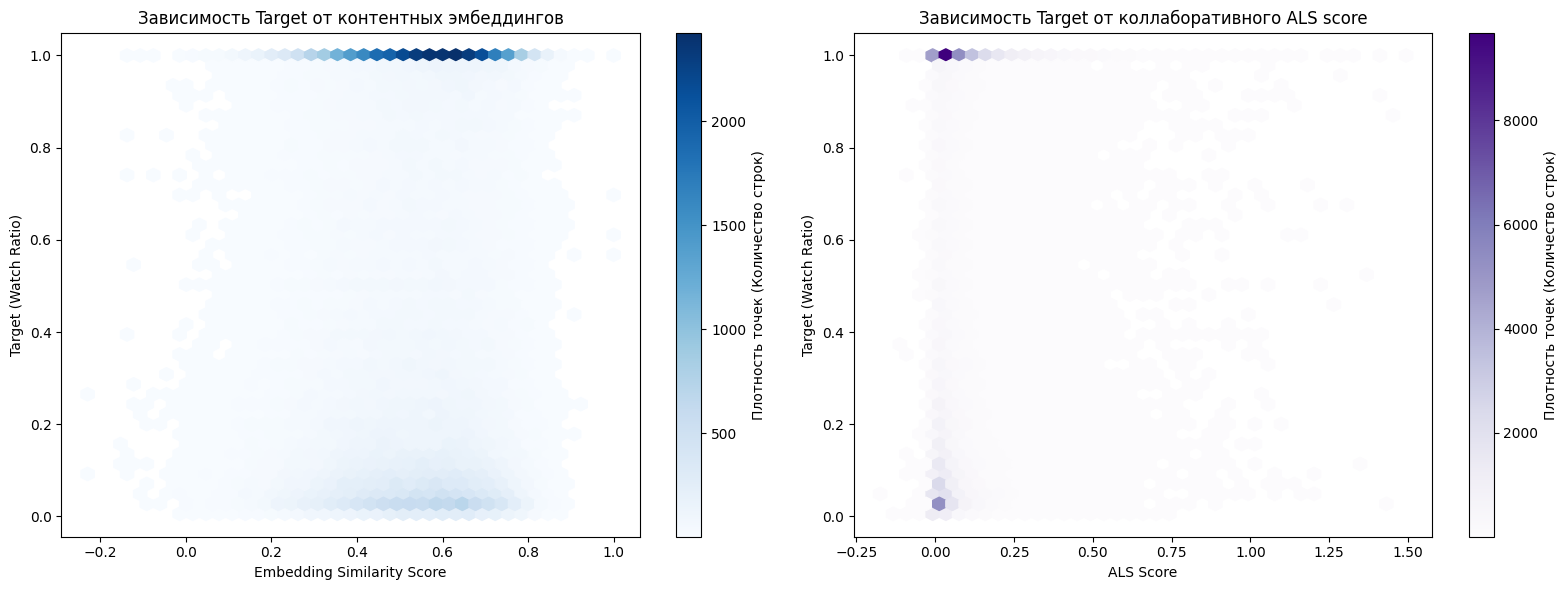

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берем небольшой сэмпл для визуализации, чтобы не перегружать память
df_plot_sample = df.sample(n=100000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Зависимость таргета от контентного сходства (Hexbin)
hb = axes[0].hexbin(df_plot_sample['embedding_similarity_score'], df_plot_sample['target'],
                    gridsize=40, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Плотность точек (Количество строк)')
axes[0].set_xlabel('Embedding Similarity Score')
axes[0].set_ylabel('Target (Watch Ratio)')
axes[0].set_title('Зависимость Target от контентных эмбеддингов')

# 2. Зависимость таргета от ALS score (Hexbin)
hb2 = axes[1].hexbin(df_plot_sample['als_score'], df_plot_sample['target'],
                     gridsize=40, cmap='Purples', mincnt=1)
fig.colorbar(hb2, ax=axes[1], label='Плотность точек (Количество строк)')
axes[1].set_xlabel('ALS Score')
axes[1].set_ylabel('Target (Watch Ratio)')
axes[1].set_title('Зависимость Target от коллаборативного ALS score')

plt.tight_layout()
plt.show()